# 07 — Junior Author EDA
Exploratory plots for junior best-paper award winners.  
**Input files:**
- `junior_profiles_all.csv` — OpenAlex author profiles (one row per unique author)
- `junior_authors_all_conferences.csv` — award-level records (one row per author × award)

Falls back to `junior_profiles.csv` / `junior_authors_2000_2018.csv` if the new files aren't ready yet.

In [6]:
import pandas as pd
import numpy as np
import json, ast, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Print-safe greyscale + hatch style
plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : 'black',
    'axes.linewidth'   : 0.8,
    'axes.grid'        : True,
    'grid.color'       : '#dddddd',
    'grid.linewidth'   : 0.6,
    'font.family'      : 'Arial',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'legend.frameon'   : True,
    'legend.edgecolor' : '#cccccc',
})

HATCHES = ['///', 'xxx', '...', '\\\\\\', '+++', '---', '|||']
GREYS   = ['#111', '#444', '#777', '#999', '#bbb', '#ddd']
MARKERS = ['o', 's', 'D', '^', 'v', 'P', '*']

os.makedirs('figures', exist_ok=True)
print('Setup complete')


Setup complete


In [7]:
PROFILES = 'B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\profiles\\junior_profiles_all.csv' 
AUTHORS  = 'B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\matched\\junior_authors_all_conferences.csv' 
profiles = pd.read_csv(PROFILES)
authors  = pd.read_csv(AUTHORS)

merged = profiles.merge(
    authors[['author_id','author_position']].drop_duplicates('author_id'),
    on='author_id', how='left'
)

print(f'Using: {PROFILES}  →  {len(profiles):,} authors')
print(profiles['conference'].value_counts().to_string())


Using: B:\Semester 4 UU\thesis-best-paper-trajectories\data\profiles\junior_profiles_all.csv  →  603 authors
conference
CHI           119
ICSE           81
FSE            47
UIST           27
PLDI           26
OSDI           22
SOSP           22
ACL            19
VLDB           18
AAAI           16
WWW            16
INFOCOM        16
SIGCOMM        12
KDD            12
SIGMOD         12
PODS           12
CIKM           12
ICML           12
CVPR           11
FOCS           11
STOC           10
IJCAI          10
SIGMETRICS      9
SIGIR           9
MOBICOM         9
ICCV            8
S&P             8
NeurIPS         7
NSDI            5
SODA            5


In [8]:
def parse_cby(raw):
    if isinstance(raw, list): return raw
    if pd.isna(raw): return []
    try:   return json.loads(raw.replace("'", '"'))
    except:
        try: return ast.literal_eval(raw)
        except: return []

rel_rows = []
for _, row in profiles.iterrows():
    for e in parse_cby(row['counts_by_year']):
        yr = e.get('year')
        if yr:
            rel_rows.append({
                'rel_year'  : yr - row['award_year'],
                'works'     : e.get('works_count', 0),
                'citations' : e.get('cited_by_count', 0),
            })

rel_df = pd.DataFrame(rel_rows)
print(f'Trajectory rows: {len(rel_df):,}')


Trajectory rows: 6,464


#### Plot 1: Career age at award

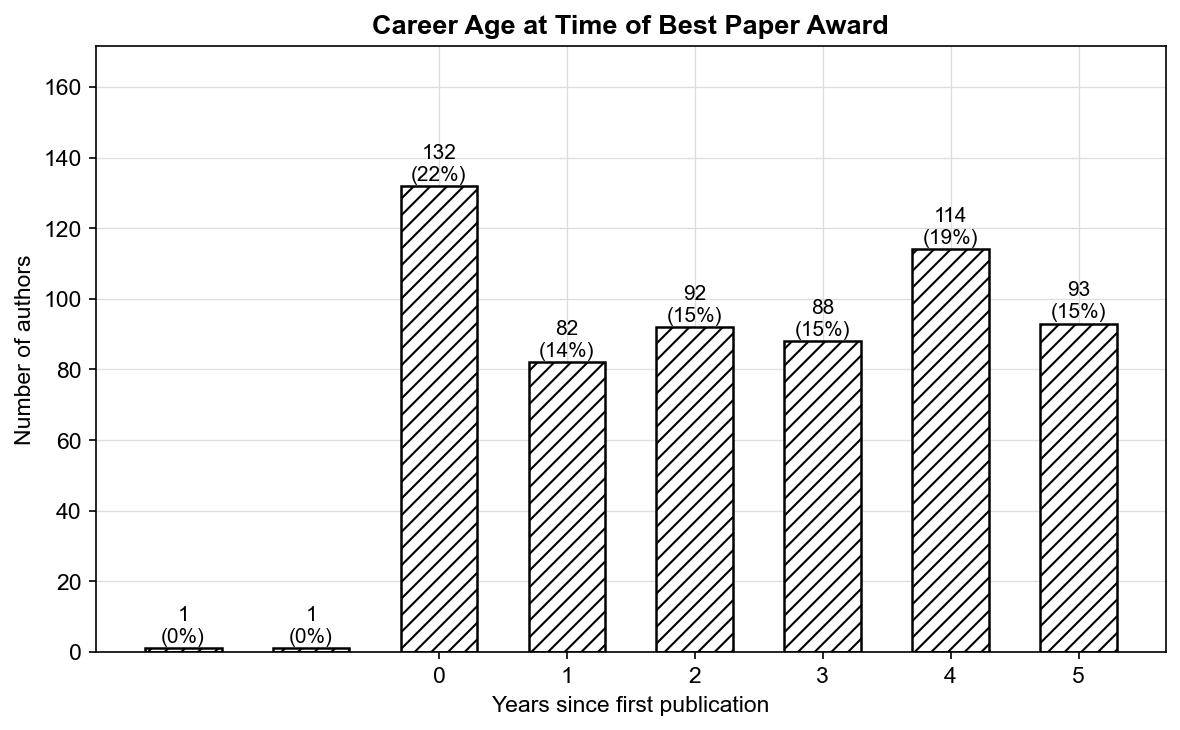

In [9]:
age = profiles['career_age_at_award'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age.index, age.values,
              color='white', edgecolor='black', linewidth=1.2,
              hatch='///', width=0.6)
for bar, val in zip(bars, age.values):
    pct = val / age.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Career Age at Time of Best Paper Award')
ax.set_xlabel('Years since first publication')
ax.set_ylabel('Number of authors')
ax.set_xticks(range(6))
ax.set_ylim(0, age.max() * 1.3)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\01_career_age.png', bbox_inches='tight')
plt.show()


The distribution is surprisingly flat from 0–5 years, with a spike at year 0 (22% of winners have literally no prior publications). This is expected given our definition of "junior" and confirms your sample captures genuinely early-career researchers, not just mid-career authors who happen to have few papers.

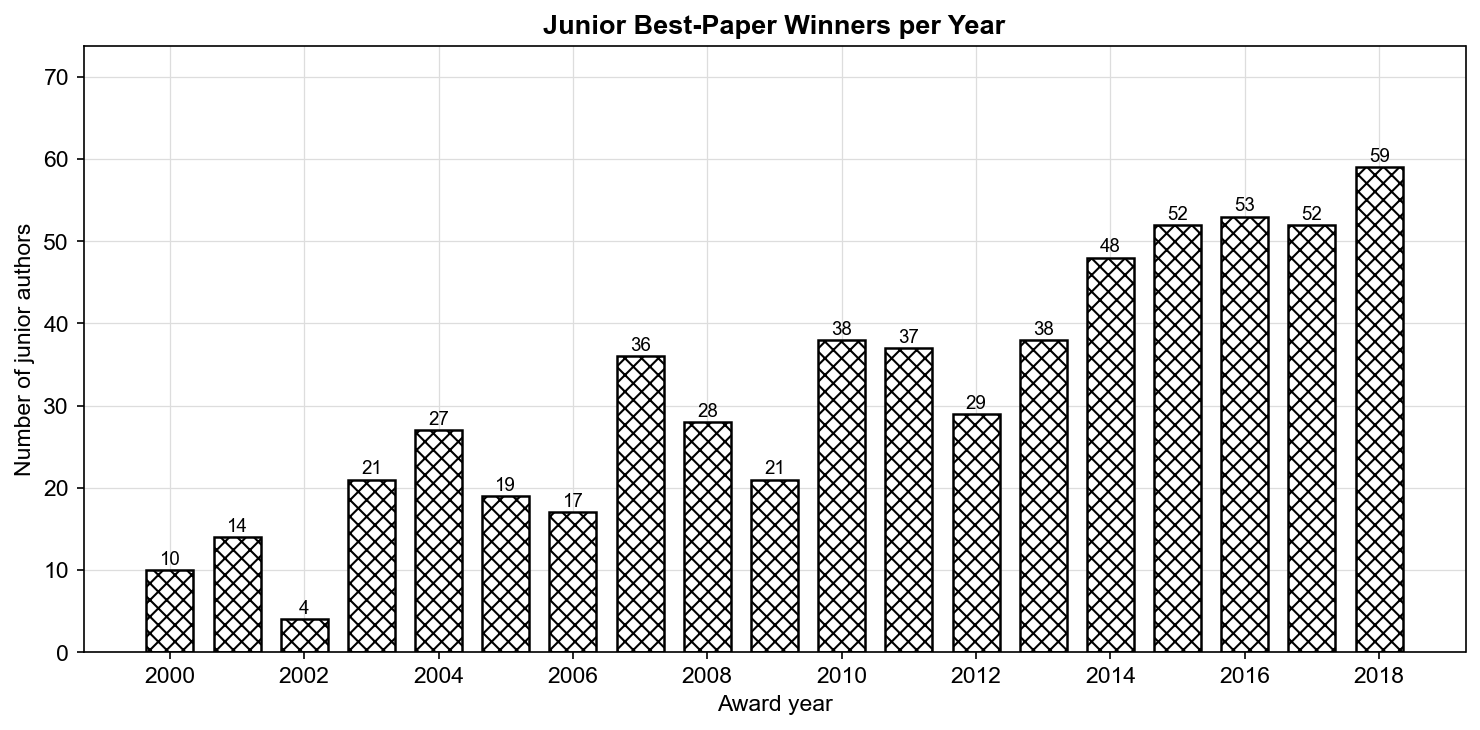

In [10]:
per_year = profiles.groupby('award_year').size()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(per_year.index, per_year.values,
              color='white', edgecolor='black', linewidth=1.2,
              hatch='xxx', width=0.7)
for bar, val in zip(bars, per_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_title('Junior Best-Paper Winners per Year')
ax.set_xlabel('Award year')
ax.set_ylabel('Number of junior authors')
ax.set_xticks(per_year.index[::2])
ax.set_ylim(0, per_year.max() * 1.25)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\02_per_year.png', bbox_inches='tight')
plt.show()


There's a clear upward trend from ~10 winners in 2000 to ~59 in 2018, roughly tripling over the period. This partly reflects our dataset growing (more conferences added in later years), so we have to be careful not to interpret this as "CS is producing more junior stars" without normalising by the number of awards given per year.

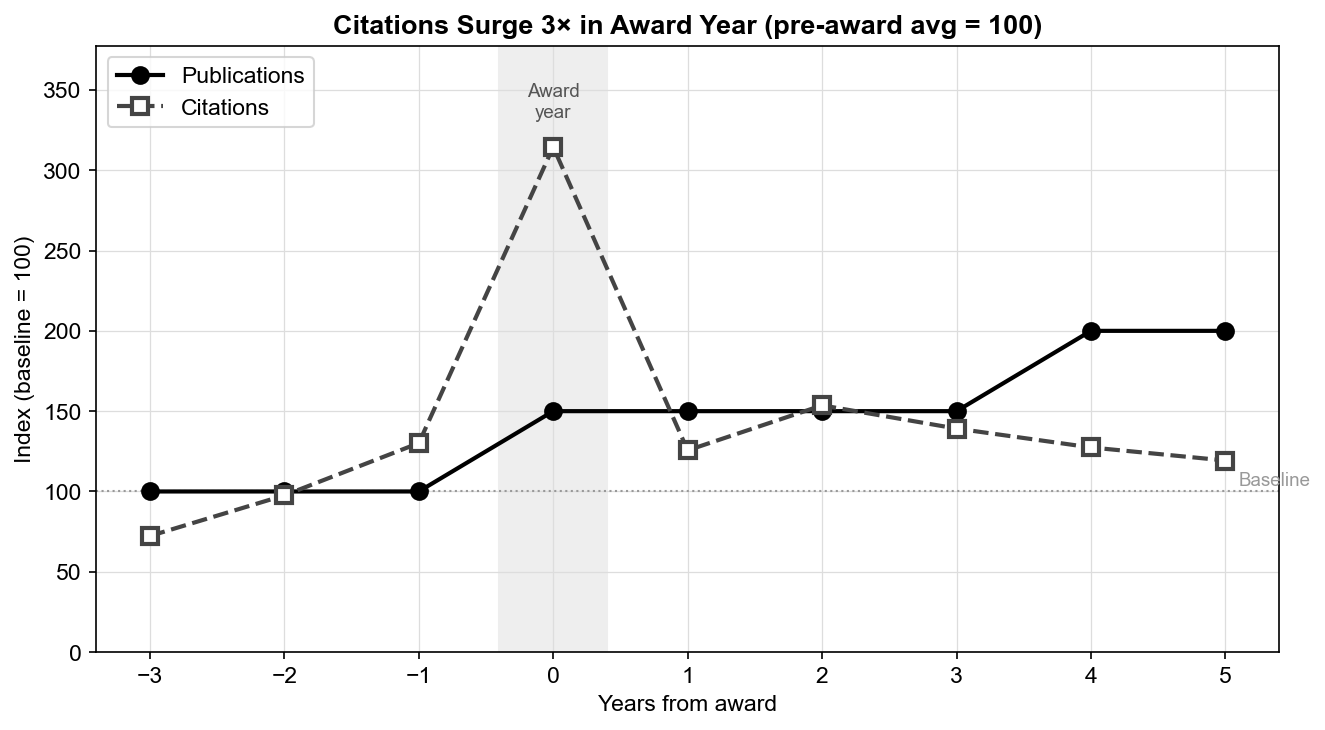

In [11]:
window = rel_df[rel_df['rel_year'].between(-3, 5)]
traj = window.groupby('rel_year').agg(
    mw=('works','median'), mc=('citations','median')
).reset_index()

base_w = traj[traj['rel_year'] < 0]['mw'].mean()
base_c = traj[traj['rel_year'] < 0]['mc'].mean()
traj['nw'] = (traj['mw'] / base_w * 100).clip(lower=0)
traj['nc'] = (traj['mc'] / base_c * 100).clip(lower=0)

fig, ax = plt.subplots(figsize=(9, 5))

# Baseline
ax.axhline(100, color='#999', linewidth=1, linestyle=':', zorder=1)
ax.text(5.1, 101, 'Baseline', color='#999', fontsize=9, va='bottom')

# Award year shading
ax.axvspan(-0.4, 0.4, color='#eeeeee', zorder=0, label='_nolegend_')
ax.text(0, traj['nc'].max() * 1.05, 'Award\nyear',
        ha='center', va='bottom', fontsize=9, color='#555')

# Lines
ax.plot(traj['rel_year'], traj['nw'], color='black', linewidth=2,
        linestyle='-', marker='o', markersize=8, label='Publications')
ax.plot(traj['rel_year'], traj['nc'], color='#444', linewidth=2,
        linestyle='--', marker='s', markersize=8,
        markerfacecolor='white', markeredgecolor='#444', markeredgewidth=2,
        label='Citations')

ax.set_title('Citations Surge 3× in Award Year (pre-award avg = 100)')
ax.set_xlabel('Years from award')
ax.set_ylabel('Index (baseline = 100)')
ax.set_xticks(range(-3, 6))
ax.set_ylim(0, traj['nc'].max() * 1.2)
ax.legend(loc='upper left')
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\03_trajectory.png', bbox_inches='tight')
plt.show()


The citation spike at year 0 (3×) is the most compelling finding — it strongly suggests the award paper itself generates a burst of attention. Publications also rise and stay elevated after the award, consistent with an early-career boost, though the effect is more gradual than the citation spike.

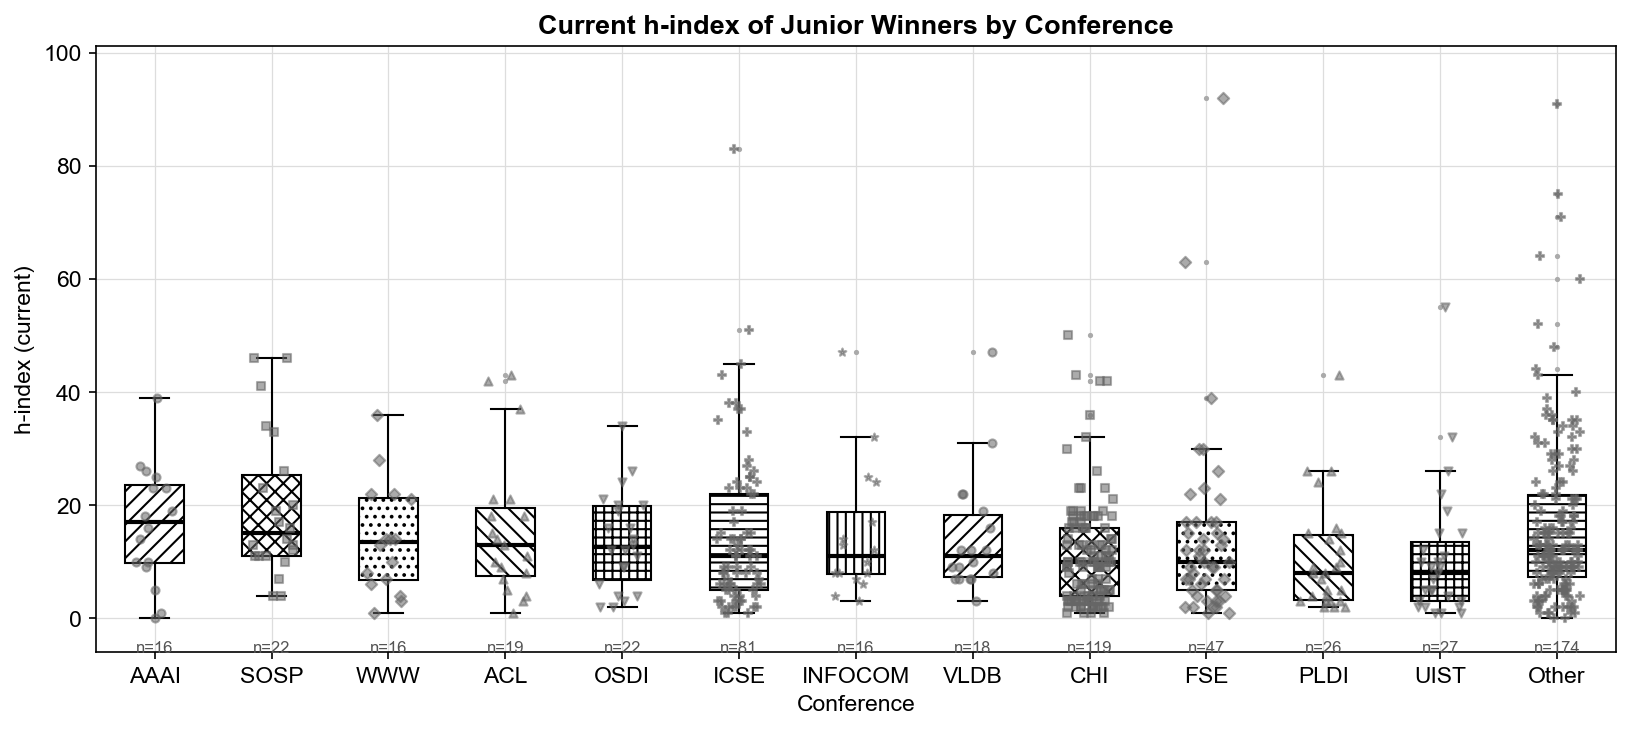

In [22]:
# Keep only conferences with enough authors, group the rest as "Other"
MIN_N = 13
conf_counts = profiles['conference'].value_counts()
keep = conf_counts[conf_counts >= MIN_N].index.tolist()

df_plot = profiles.copy()
df_plot['conf_group'] = df_plot['conference'].where(df_plot['conference'].isin(keep), other='Other')

conf_order = (df_plot.groupby('conf_group')['h_index']
              .median().sort_values(ascending=False).index.tolist())
# Put "Other" last
if 'Other' in conf_order:
    conf_order = [c for c in conf_order if c != 'Other'] + ['Other']

fig, ax = plt.subplots(figsize=(11, 5))

data = [df_plot.loc[df_plot['conf_group']==c, 'h_index'].dropna().values for c in conf_order]
bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='.', markersize=3, markerfacecolor='#aaa', markeredgecolor='#aaa'))

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('white')
    patch.set_hatch(HATCHES[i % len(HATCHES)])
    patch.set_edgecolor('black')

# Jittered points
for i, (vals, conf) in enumerate(zip(data, conf_order)):
    jitter = np.random.uniform(-0.2, 0.2, size=len(vals))
    ax.scatter(np.full(len(vals), i+1) + jitter, vals,
               marker=MARKERS[i % len(MARKERS)],
               color='#666', s=15, alpha=0.55, zorder=3)

# Annotate n per conference
for i, (vals, conf) in enumerate(zip(data, conf_order)):
    ax.text(i+1, -4, f'n={len(vals)}', ha='center', va='top', fontsize=8, color='#555')

ax.set_title('Current h-index of Junior Winners by Conference')
ax.set_xlabel('Conference')
ax.set_ylabel('h-index (current)')
ax.set_xticks(range(1, len(conf_order)+1))
ax.set_xticklabels(conf_order, rotation=0)
ax.set_ylim(-6, df_plot['h_index'].max() * 1.1)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\04_hindex.png', bbox_inches='tight')
plt.show()


Medians are remarkably similar across all venues (around 10–20), suggesting junior award winners end up with comparable long-run impact regardless of where they first won. SOSP and AAAI show slightly higher medians, but the wide spread in every box means conference choice alone doesn't predict career success.

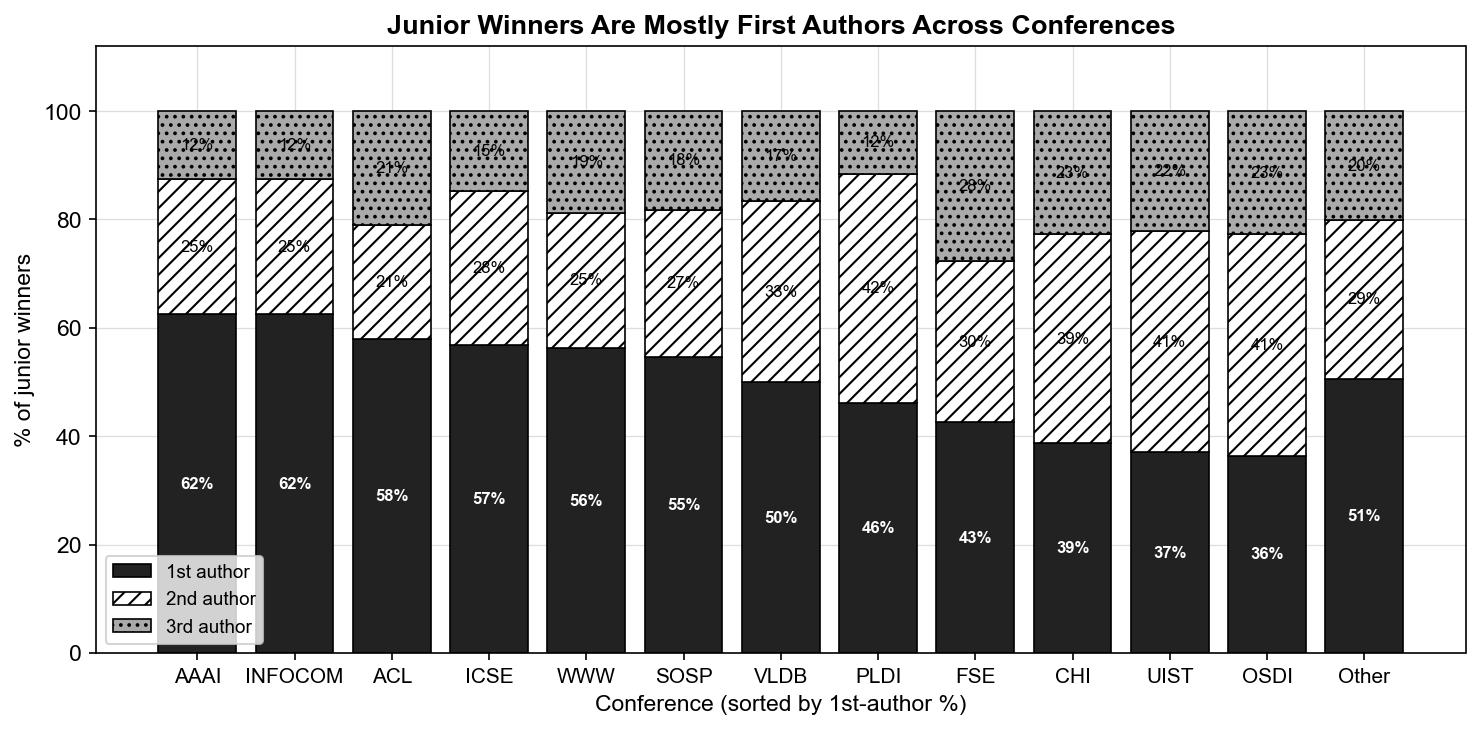

In [23]:
# Use authors file directly, same MIN_N threshold
pos = authors.groupby(['conference','author_position']).size().reset_index(name='n')
pos['conf_group'] = pos['conference'].where(pos['conference'].isin(keep), other='Other')
pos_grp = pos.groupby(['conf_group','author_position'])['n'].sum().reset_index()

conf_totals = pos_grp.groupby('conf_group')['n'].sum()

# Sort by 1st-author % descending (tells a cleaner story)
first_pct = (pos_grp[pos_grp['author_position']==1]
             .set_index('conf_group')['n']
             .reindex(conf_totals.index).fillna(0) / conf_totals * 100)
conf_order2 = first_pct.sort_values(ascending=False).index.tolist()
if 'Other' in conf_order2:
    conf_order2 = [c for c in conf_order2 if c != 'Other'] + ['Other']

pct = {}
for p in [1, 2, 3]:
    sub = (pos_grp[pos_grp['author_position']==p]
           .set_index('conf_group').reindex(conf_order2)['n'].fillna(0))
    pct[p] = (sub / conf_totals.reindex(conf_order2) * 100).values

x = np.arange(len(conf_order2))
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x, pct[1], color='#222', edgecolor='black', linewidth=0.8, label='1st author')
ax.bar(x, pct[2], bottom=pct[1],
       color='white', hatch='///', edgecolor='black', linewidth=0.8, label='2nd author')
ax.bar(x, pct[3], bottom=pct[1]+pct[2],
       color='#aaa', hatch='...', edgecolor='black', linewidth=0.8, label='3rd author')

# Only label segments > 8% to avoid clutter
for i in range(len(conf_order2)):
    if pct[1][i] > 8:
        ax.text(i, pct[1][i]/2,
                f"{pct[1][i]:.0f}%", ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if pct[2][i] > 8:
        ax.text(i, pct[1][i] + pct[2][i]/2,
                f"{pct[2][i]:.0f}%", ha='center', va='center', fontsize=8, color='black')
    if pct[3][i] > 8:
        ax.text(i, pct[1][i] + pct[2][i] + pct[3][i]/2,
                f"{pct[3][i]:.0f}%", ha='center', va='center', fontsize=8, color='black')

ax.set_title('Junior Winners Are Mostly First Authors Across Conferences')
ax.set_xlabel('Conference (sorted by 1st-author %)')
ax.set_ylabel('% of junior winners')
ax.set_xticks(x)
ax.set_xticklabels(conf_order2, rotation=0, fontsize=10)
ax.set_ylim(0, 112)
ax.legend(loc='lower left', fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\05_position.png', bbox_inches='tight')
plt.show()


Most conferences sit between 37–62% first-author rate for juniors, which is healthy — these authors are genuinely leading their award-winning papers. The fact that CHI and UIST sit at the low end (~37–39%) is interesting and plausible as HCI papers tend to have larger, more collaborative author lists where junior contributions are real but not always lead-positioned.

In [24]:
summary = profiles.groupby('conference').agg(
    n_juniors        =('author_id','count'),
    median_h         =('h_index','median'),
    median_career_age=('career_age_at_award','median'),
    median_citations =('cited_by_count','median'),
).round(1).sort_values('n_juniors', ascending=False)

display(summary)
summary.to_csv('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\summary_stats.csv')


,n_juniors,median_h,median_career_age,median_citations
conference,,,,
CHI,119,10.0,2.0,580.0
ICSE,81,11.0,3.0,652.0
FSE,47,10.0,2.0,778.0
UIST,27,8.0,3.0,605.0
PLDI,26,8.0,2.0,469.0
SOSP,22,15.0,3.0,1284.0
OSDI,22,12.5,2.5,1400.5
ACL,19,13.0,3.0,1578.0
VLDB,18,11.0,3.0,676.5
